# PCD Assignment 02 - Image Enhancement

**Gradien Ridholumintu**  
**25/555306/PA/23271**

This notebook tests image-enhancement methods on three different grayscale images. Each image is degraded at five increasing levels: **20%, 40%, 60%, 80%, and 100% relative severity**.

We intentionally keep the enhancement parameters fixed across the five levels to see how far one setting still works before it starts to under-correct, over-correct, or produce visible artifacts.


## 1. Images and libraries

We use three images from `skimage.data`:

- **Camera** - a general natural scene with strong edges and midtones,
- **Coins** - many small boundaries and texture,
- **Moon** - relatively smooth regions with subtle detail.

All three are resized to 320 x 320 pixels.

/opt/pyvenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


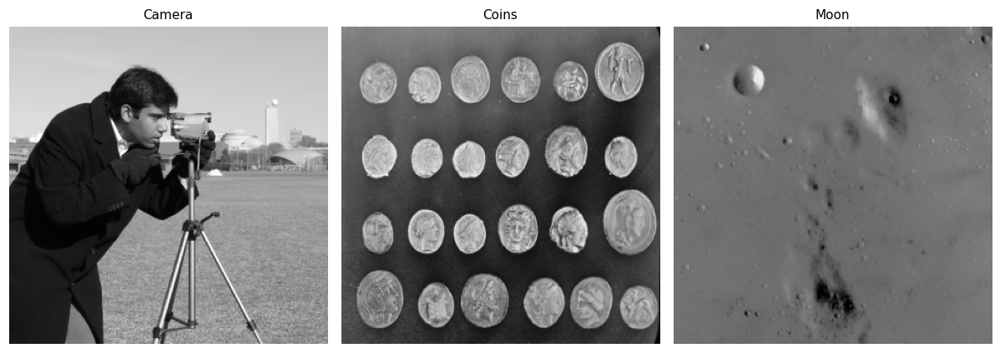

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from numpy.lib.stride_tricks import sliding_window_view
from IPython.display import display

from skimage import data, exposure, filters, transform
from skimage.util import img_as_float
from skimage.metrics import (
    mean_squared_error,
    peak_signal_noise_ratio,
    structural_similarity,
)

# configure matplotlib
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
})

def clip01(image):
    return np.clip(image, 0.0, 1.0)

def prepare_image(image, size=(320, 320)):
    image = img_as_float(image)
    return transform.resize(
        image,
        size,
        preserve_range=True,
        anti_aliasing=True,
    )

def show_image_row(images, titles, figsize=(11, 4)):
    fig, axes = plt.subplots(1, len(images), figsize=figsize)
    if len(images) == 1:
        axes = [axes]

    for ax, image, title in zip(axes, images, titles):
        ax.imshow(image, cmap="gray", vmin=0, vmax=1)
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

def evaluate(reference, candidate):
    return {
        "MSE": mean_squared_error(reference, candidate),
        "PSNR (dB)": peak_signal_noise_ratio(
            reference, candidate, data_range=1.0
        ),
        "SSIM": structural_similarity(
            reference, candidate, data_range=1.0
        ),
    }

images = {
    "Camera": prepare_image(data.camera()),
    "Coins": prepare_image(data.coins()),
    "Moon": prepare_image(data.moon()),
}

show_image_row(
    list(images.values()),
    list(images.keys()),
)

## 2. Degradation levels

Five levels are used for every degradation type.

The dark and bright cases use a power-law change plus a small gain adjustment. The low-contrast case compresses the intensity range and also increases the nonlinear distortion. Blur is generated with a Gaussian filter whose sigma increases at each level.

In [2]:
SEVERITIES = [20, 40, 60, 80, 100]

# parameters for each severity level
DARK_GAMMA = {20: 2.0, 40: 2.5, 60: 3.0, 80: 3.5, 100: 4.0}
DARK_GAIN  = {20: 0.94, 40: 0.89, 60: 0.84, 80: 0.79, 100: 0.74}

BRIGHT_GAMMA = {20: 0.72, 40: 0.60, 60: 0.48, 80: 0.36, 100: 0.24}
BRIGHT_GAIN  = {20: 1.02, 40: 1.04, 60: 1.06, 80: 1.08, 100: 1.10}

LOW_FACTOR = {20: 0.55, 40: 0.45, 60: 0.35, 80: 0.25, 100: 0.15}
LOW_GAMMA  = {20: 1.10, 40: 1.20, 60: 1.35, 80: 1.55, 100: 1.80}

BLUR_SIGMA = {20: 1.5, 40: 2.4, 60: 3.3, 80: 4.2, 100: 5.1}

severity_parameters = pd.DataFrame({
    "Severity": SEVERITIES,
    "Dark gamma": [DARK_GAMMA[s] for s in SEVERITIES],
    "Dark gain": [DARK_GAIN[s] for s in SEVERITIES],
    "Bright gamma": [BRIGHT_GAMMA[s] for s in SEVERITIES],
    "Bright gain": [BRIGHT_GAIN[s] for s in SEVERITIES],
    "Low-contrast factor": [LOW_FACTOR[s] for s in SEVERITIES],
    "Low-contrast gamma": [LOW_GAMMA[s] for s in SEVERITIES],
    "Blur sigma": [BLUR_SIGMA[s] for s in SEVERITIES],
}).set_index("Severity")

display(severity_parameters)

,Dark gamma,Dark gain,Bright gamma,Bright gain,Low-contrast factor,Low-contrast gamma,Blur sigma
Severity,,,,,,,
20,2.0,0.94,0.72,1.02,0.55,1.10,1.5
40,2.5,0.89,0.60,1.04,0.45,1.20,2.4
60,3.0,0.84,0.48,1.06,0.35,1.35,3.3
80,3.5,0.79,0.36,1.08,0.25,1.55,4.2
100,4.0,0.74,0.24,1.10,0.15,1.80,5.1


In [3]:
def make_dark(image, severity):
    corrected = exposure.adjust_gamma(
        image,
        gamma=DARK_GAMMA[severity],
    )
    return clip01(corrected * DARK_GAIN[severity])

def make_bright(image, severity):
    corrected = exposure.adjust_gamma(
        image,
        gamma=BRIGHT_GAMMA[severity],
    )
    return clip01(corrected * BRIGHT_GAIN[severity])

def make_low_contrast(image, severity):
    shaped = exposure.adjust_gamma(
        image,
        gamma=LOW_GAMMA[severity],
    )
    compressed = (
        0.5
        + LOW_FACTOR[severity] * (shaped - 0.5)
    )
    return clip01(compressed)

def make_blurred(image, severity):
    return filters.gaussian(
        image,
        sigma=BLUR_SIGMA[severity],
        preserve_range=True,
    )

# function to build the varying degradations
def build_levels(source_images, degradation_function):
    return {
        severity: {
            name: degradation_function(image, severity)
            for name, image in source_images.items()
        }
        for severity in SEVERITIES
    }

dark_levels = build_levels(images, make_dark)
bright_levels = build_levels(images, make_bright)
low_levels = build_levels(images, make_low_contrast)
blur_levels = build_levels(images, make_blurred)

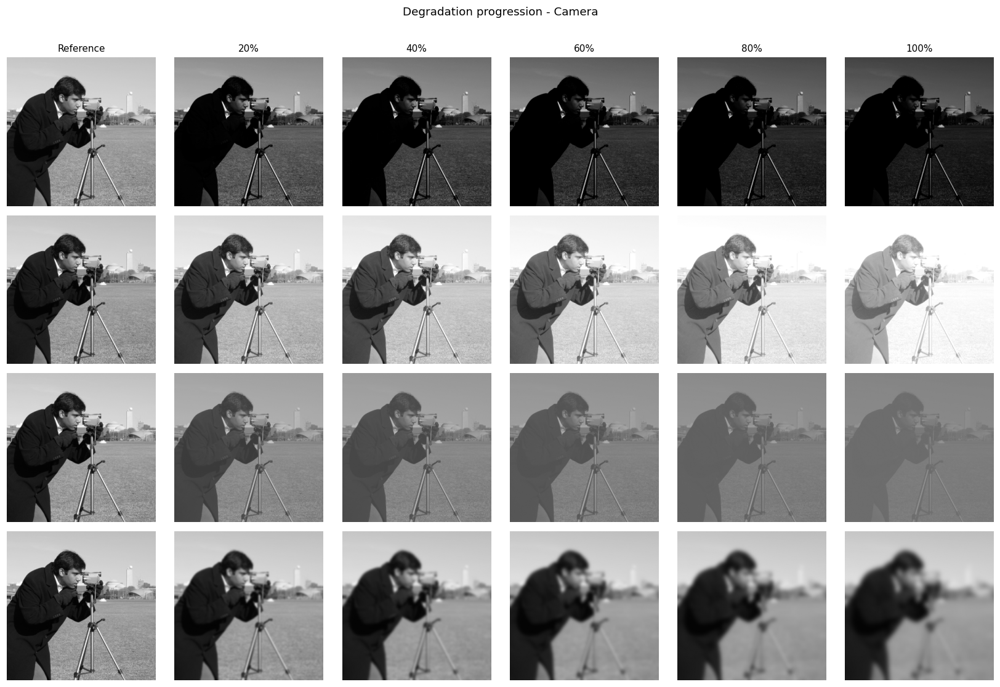

In [4]:
def show_degradation_overview(image_name):
    problems = [
        ("Dark", dark_levels),
        ("Bright", bright_levels),
        ("Low contrast", low_levels),
        ("Blur", blur_levels),
    ]

    fig, axes = plt.subplots(
        len(problems),
        6,
        figsize=(15, 10),
        squeeze=False,
    )

    for row, (problem_name, levels) in enumerate(problems):
        axes[row, 0].imshow(
            images[image_name],
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        axes[row, 0].set_title("Reference" if row == 0 else "")
        axes[row, 0].set_ylabel(
            problem_name,
            rotation=0,
            labelpad=40,
            va="center",
        )
        axes[row, 0].axis("off")

        for col, severity in enumerate(SEVERITIES, start=1):
            axes[row, col].imshow(
                levels[severity][image_name],
                cmap="gray",
                vmin=0,
                vmax=1,
            )
            if row == 0:
                axes[row, col].set_title(f"{severity}%")
            axes[row, col].axis("off")

    fig.suptitle(
        f"Degradation progression - {image_name}",
        y=1.01,
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()

show_degradation_overview("Camera")


 As we can see, the 20% cases already have visible degradation, while the 80% and 100% cases are intentionally difficult. In the bright-image sequence, the strongest levels also start clipping highlights. Once clipping happens, an enhancement method can change the remaining tones but cannot recover the original clipped values.

## 3. Shared evaluation and plotting functions

For every problem, all three images and all five degradation levels are evaluated.

We use:

- **MSE** - lower is better,
- **PSNR** - higher is better,
- **SSIM** - higher is better.

In [5]:
def apply_method_to_levels(levels, method):
    return {
        severity: {
            name: method(image)
            for name, image in levels[severity].items()
        }
        for severity in SEVERITIES
    }

def evaluate_problem(references, degraded_levels, method_outputs):
    rows = []

    for severity in SEVERITIES:
        for image_name, reference in references.items():
            rows.append({
                "Image": image_name,
                "Severity": severity,
                "Method": "Degraded input",
                **evaluate(
                    reference,
                    degraded_levels[severity][image_name],
                ),
            })

            for method_name, outputs in method_outputs.items():
                rows.append({
                    "Image": image_name,
                    "Severity": severity,
                    "Method": method_name,
                    **evaluate(
                        reference,
                        outputs[severity][image_name],
                    ),
                })

    return pd.DataFrame(rows)

def average_metrics(results):
    return (
        results
        .groupby(["Severity", "Method"], sort=False)[
            ["MSE", "PSNR (dB)", "SSIM"]
        ]
        .mean()
        .reset_index()
    )

def plot_ssim_trend(average_table, title):
    fig, ax = plt.subplots(figsize=(7.5, 4.5))

    for method, group in average_table.groupby("Method", sort=False):
        group = group.sort_values("Severity")
        ax.plot(
            group["Severity"],
            group["SSIM"],
            marker="o",
            label=method,
        )

    ax.set_title(title)
    ax.set_xlabel("Relative degradation severity (%)")
    ax.set_ylabel("Average SSIM")
    ax.set_xticks(SEVERITIES)
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()

def show_input_progression(levels, title):
    fig, axes = plt.subplots(
        len(images),
        len(SEVERITIES),
        figsize=(14, 8),
        squeeze=False,
    )

    for row, image_name in enumerate(images):
        for col, severity in enumerate(SEVERITIES):
            axes[row, col].imshow(
                levels[severity][image_name],
                cmap="gray",
                vmin=0,
                vmax=1,
            )
            axes[row, col].axis("off")

            if row == 0:
                axes[row, col].set_title(f"{severity}%")

            if col == 0:
                axes[row, col].set_ylabel(
                    image_name,
                    rotation=0,
                    labelpad=35,
                    va="center",
                )

    fig.suptitle(title, y=1.01, fontsize=12)
    plt.tight_layout()
    plt.show()

def show_enhancement_progression(method_outputs, title):
    method_names = list(method_outputs.keys())
    n_rows = len(images) * len(method_names)

    fig, axes = plt.subplots(
        n_rows,
        len(SEVERITIES),
        figsize=(14, 2.55 * n_rows),
        squeeze=False,
    )

    row = 0
    for image_name in images:
        for method_name in method_names:
            for col, severity in enumerate(SEVERITIES):
                axes[row, col].imshow(
                    method_outputs[method_name][severity][image_name],
                    cmap="gray",
                    vmin=0,
                    vmax=1,
                )
                axes[row, col].axis("off")

                if row == 0:
                    axes[row, col].set_title(f"{severity}%")

                if col == 0:
                    axes[row, col].set_ylabel(
                        f"{image_name}\n{method_name}",
                        rotation=0,
                        labelpad=55,
                        va="center",
                    )

            row += 1

    fig.suptitle(title, y=1.005, fontsize=12)
    plt.tight_layout()
    plt.show()

## 4. Dark-image enhancement

The log transform is

$$
s = c\log(1+r)
$$

For a normalized image with $r \in [0,1]$, we use

$$
c = \frac{1}{\log 2}
$$

so that $r=1$ maps to $s=1$.

W also test a fixed power-law transformation:

$$
s = r^{\gamma}
$$

with $\gamma=0.45$. Since $\gamma<1$, dark intensities are expanded upward.


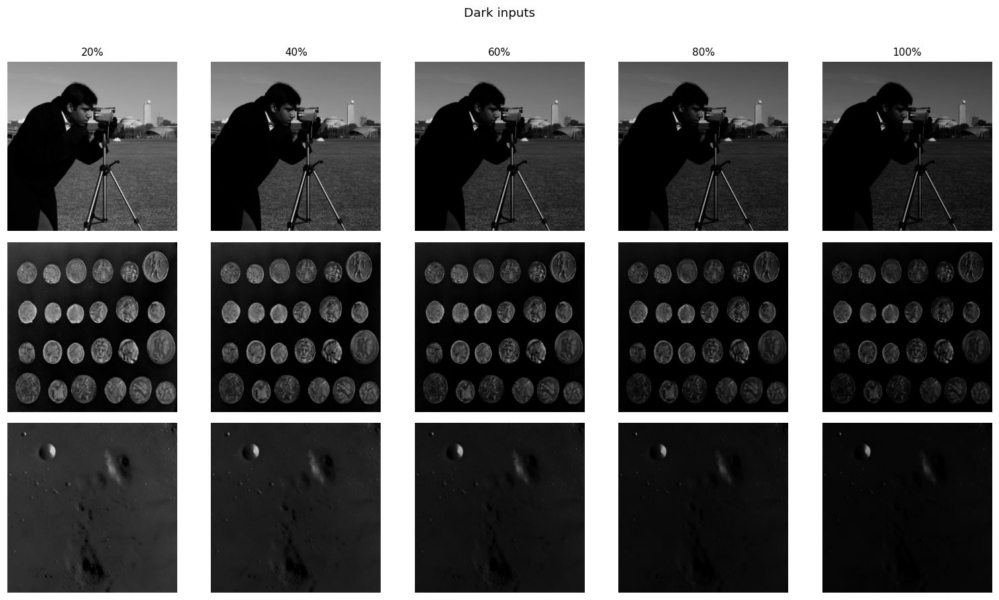

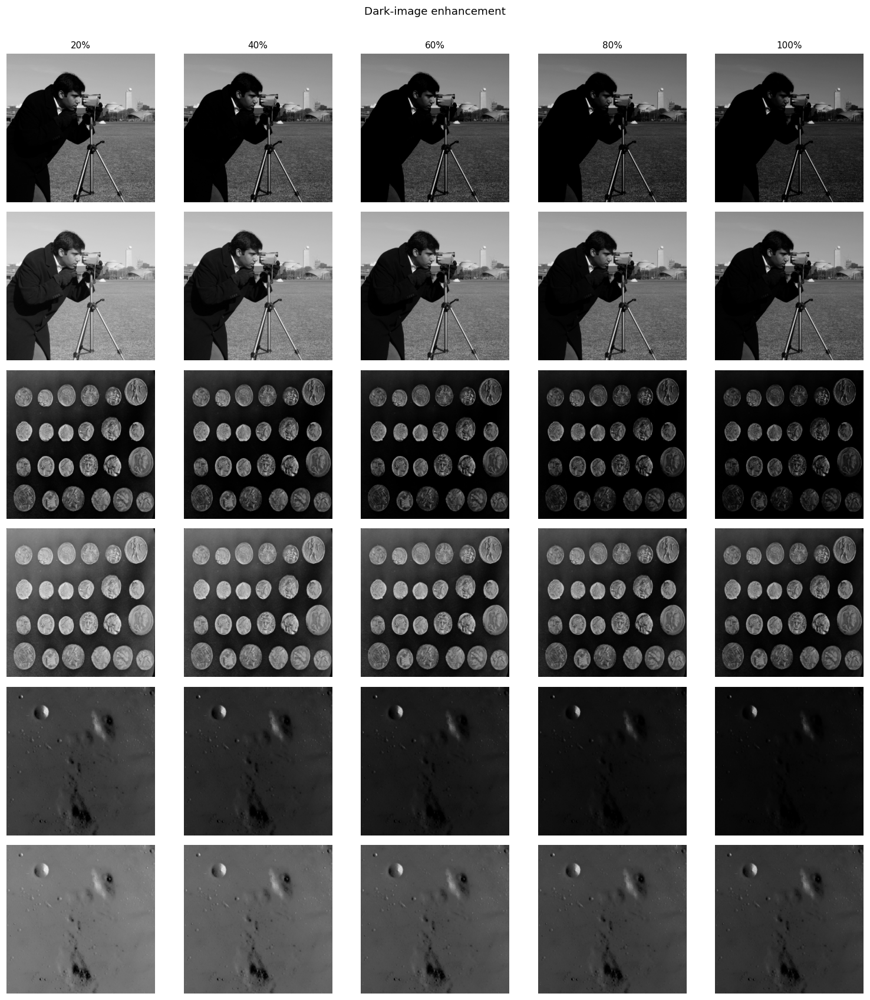

,Severity,Method,MSE,PSNR (dB),SSIM
0,20,Degraded input,0.05049,13.06,0.6630
1,20,Log transform,0.02850,15.62,0.7704
2,20,Gamma 0.45,0.00047,33.56,0.9947
3,40,Degraded input,0.08431,10.80,0.4905
4,40,Log transform,0.05951,12.37,0.5977
5,40,Gamma 0.45,0.00337,24.76,0.9816
6,60,Degraded input,0.11353,9.49,0.3607
7,60,Log transform,0.08927,10.57,0.4548
8,60,Gamma 0.45,0.01451,18.44,0.9052
9,80,Degraded input,0.13757,8.65,0.2662


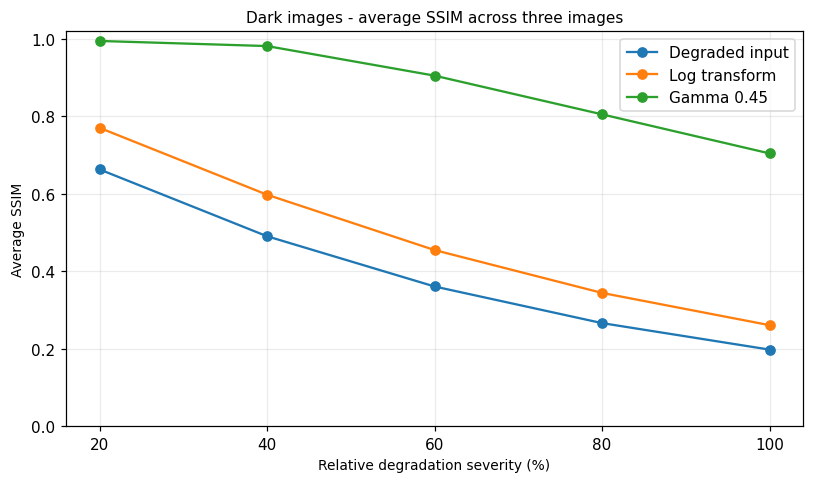

In [6]:
def log_transform(image):
    image = clip01(image.astype(np.float64))
    c = 1.0 / np.log(2.0)
    return clip01(c * np.log1p(image))

def gamma_transform(image, gamma):
    image = clip01(image.astype(np.float64))
    return clip01(np.power(image, gamma))

dark_log = apply_method_to_levels(
    dark_levels,
    log_transform,
)

dark_gamma = apply_method_to_levels(
    dark_levels,
    lambda image: gamma_transform(image, gamma=0.45),
)

dark_methods = {
    "Log transform": dark_log,
    "Gamma 0.45": dark_gamma,
}

show_input_progression(
    dark_levels,
    "Dark inputs",
)

show_enhancement_progression(
    dark_methods,
    "Dark-image enhancement",
)

dark_results = evaluate_problem(
    images,
    dark_levels,
    dark_methods,
)
dark_average = average_metrics(dark_results)

display(
    dark_average.round({
        "MSE": 5,
        "PSNR (dB)": 2,
        "SSIM": 4,
    })
)

plot_ssim_trend(
    dark_average,
    "Dark images - average SSIM across three images",
)

### Observation

Gamma 0.45 is close to the reference at 20% and 40%, but the same fixed value starts to under-correct the image from about 60% onward. The SSIM curve then falls noticeably at 80% and 100%.

The log transform improves the dark inputs, but for these deliberately severe degradations it is not strong enough to bring the range back close to the reference.

## 5. Bright-image enhancement

For an overly bright image we use the same power-law form,

$$
s = r^{\gamma}
$$

but now with $\gamma>1$.

We compare two fixed values, $\gamma=1.8$ and $\gamma=2.4$  to see how the useful range changes as the input becomes brighter.

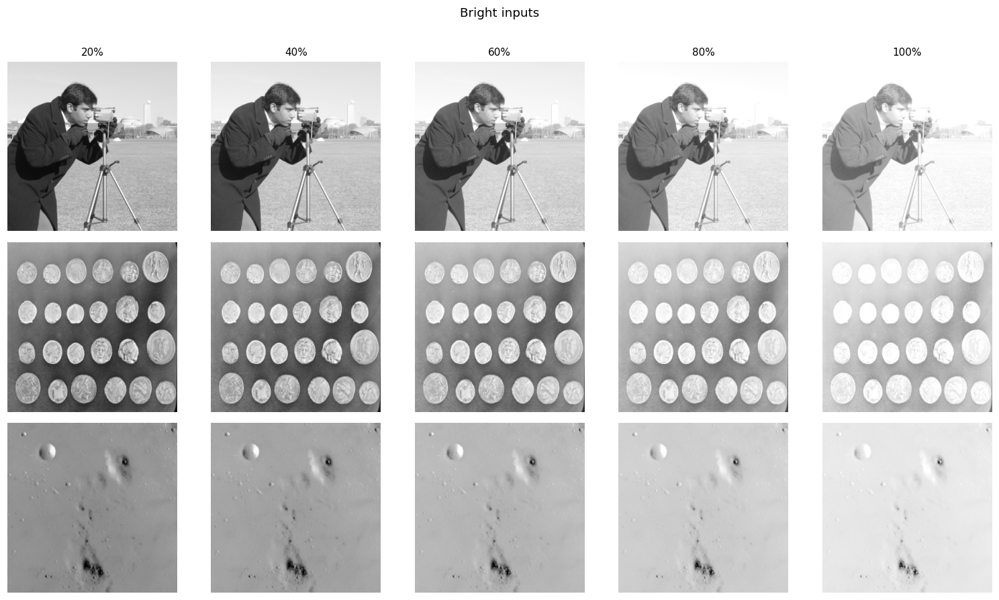

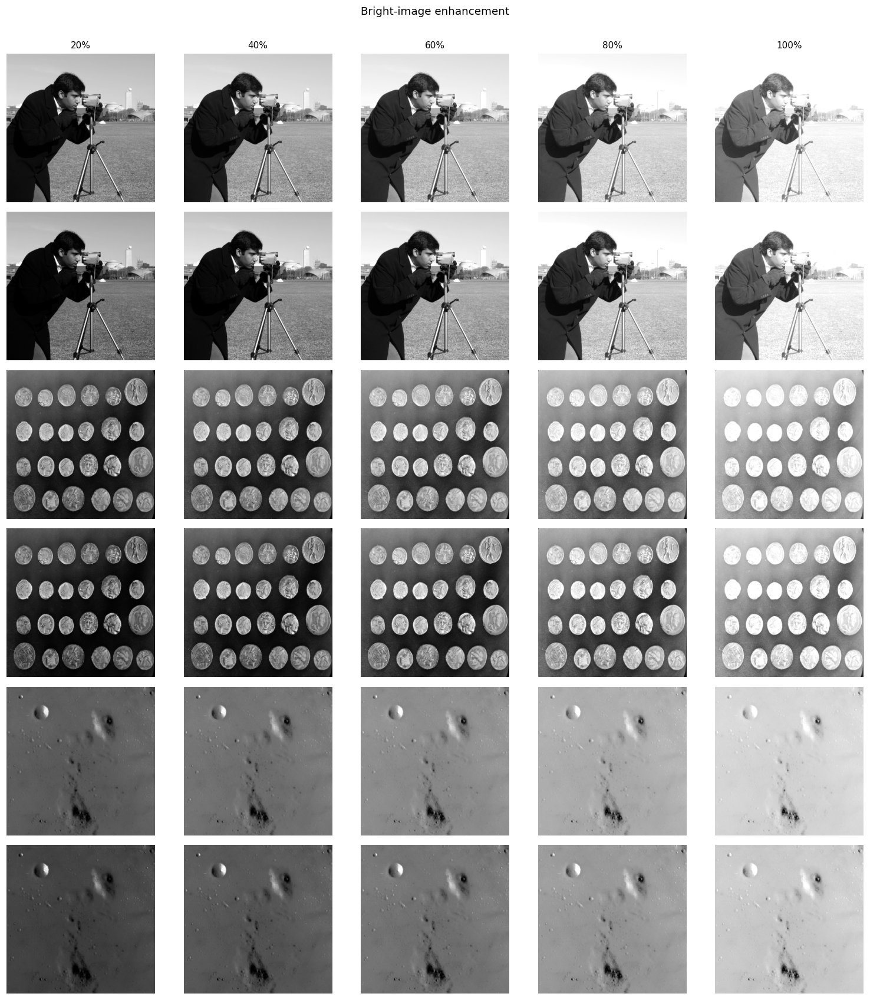

,Severity,Method,MSE,PSNR (dB),SSIM
0,20,Degraded input,0.01232,19.22,0.9435
1,20,Gamma 1.8,0.00473,23.55,0.9540
2,20,Gamma 2.4,0.02407,16.41,0.8029
3,40,Degraded input,0.03112,15.18,0.8906
4,40,Gamma 1.8,0.00035,37.96,0.9971
5,40,Gamma 2.4,0.00715,21.86,0.9201
6,60,Degraded input,0.06357,12.06,0.8273
7,60,Gamma 1.8,0.01006,19.99,0.9668
8,60,Gamma 2.4,0.00144,31.52,0.9894
9,80,Degraded input,0.11594,9.43,0.7520


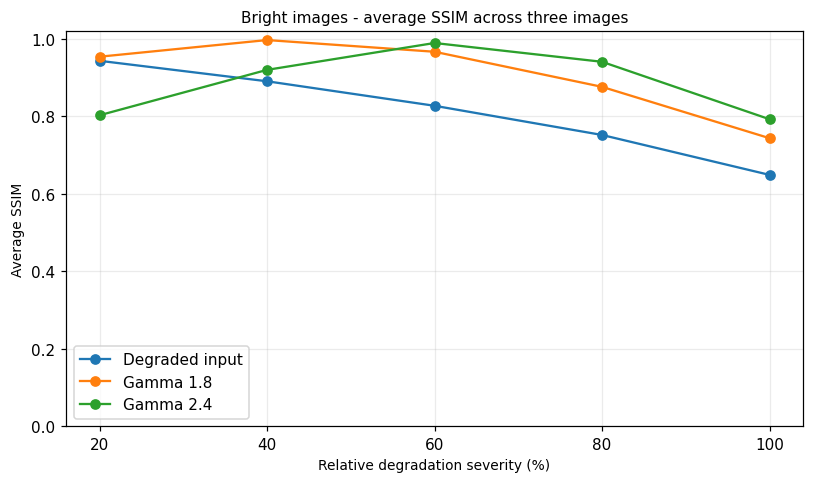

In [7]:
bright_gamma_18 = apply_method_to_levels(
    bright_levels,
    lambda image: gamma_transform(image, gamma=1.8),
)

bright_gamma_24 = apply_method_to_levels(
    bright_levels,
    lambda image: gamma_transform(image, gamma=2.4),
)

bright_methods = {
    "Gamma 1.8": bright_gamma_18,
    "Gamma 2.4": bright_gamma_24,
}

show_input_progression(
    bright_levels,
    "Bright inputs",
)

show_enhancement_progression(
    bright_methods,
    "Bright-image enhancement",
)

bright_results = evaluate_problem(
    images,
    bright_levels,
    bright_methods,
)
bright_average = average_metrics(bright_results)

display(
    bright_average.round({
        "MSE": 5,
        "PSNR (dB)": 2,
        "SSIM": 4,
    })
)

plot_ssim_trend(
    bright_average,
    "Bright images - average SSIM across three images",
)

### Observation

Gamma 1.8 works better for the milder bright images, while gamma 2.4 becomes more suitable around the middle and high severities. A stronger correction can over-darken a mild case but help a more severe one.

At the highest severity, both curves drop because the degradation has already clipped some bright pixels. No gamma value can reconstruct intensity differences that were clipped to the same maximum value.

## 6. Low-contrast enhancement

### Contrast stretching

$$
P_{\mathrm{out}}
=
\left(P_{\mathrm{in}}-P_{\min}\right)
\frac{b-a}{P_{\max}-P_{\min}}
+a
$$

For normalized images, we use $a=0$ and $b=1$.

### Histogram equalization

The manual histogram-equalization implementation follows the cumulative-distribution approach. For 256 gray levels,

$$
s_k
=
\left\lfloor
255\,\mathrm{CDF}(r_k)
\right\rfloor
$$

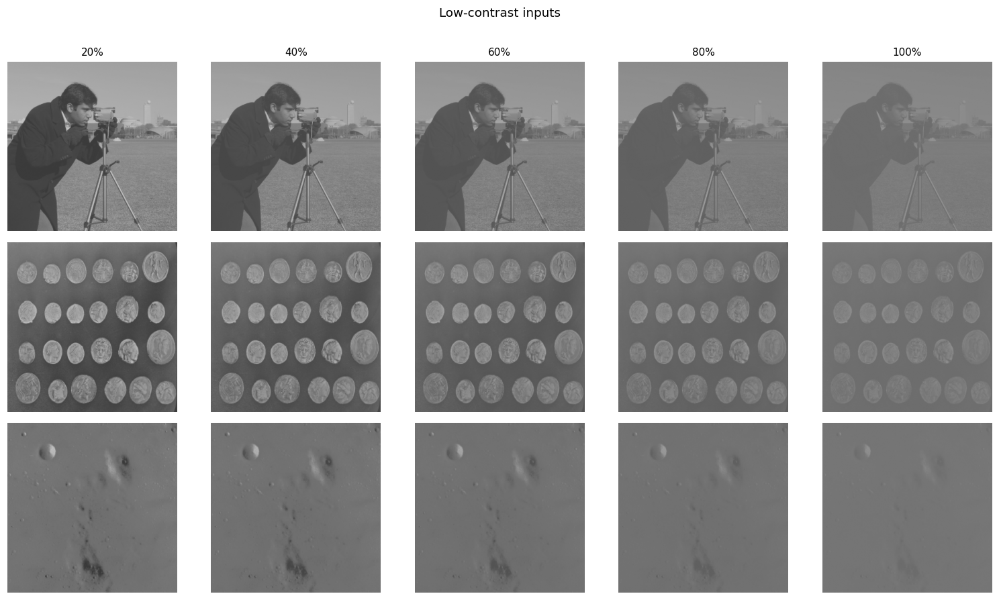

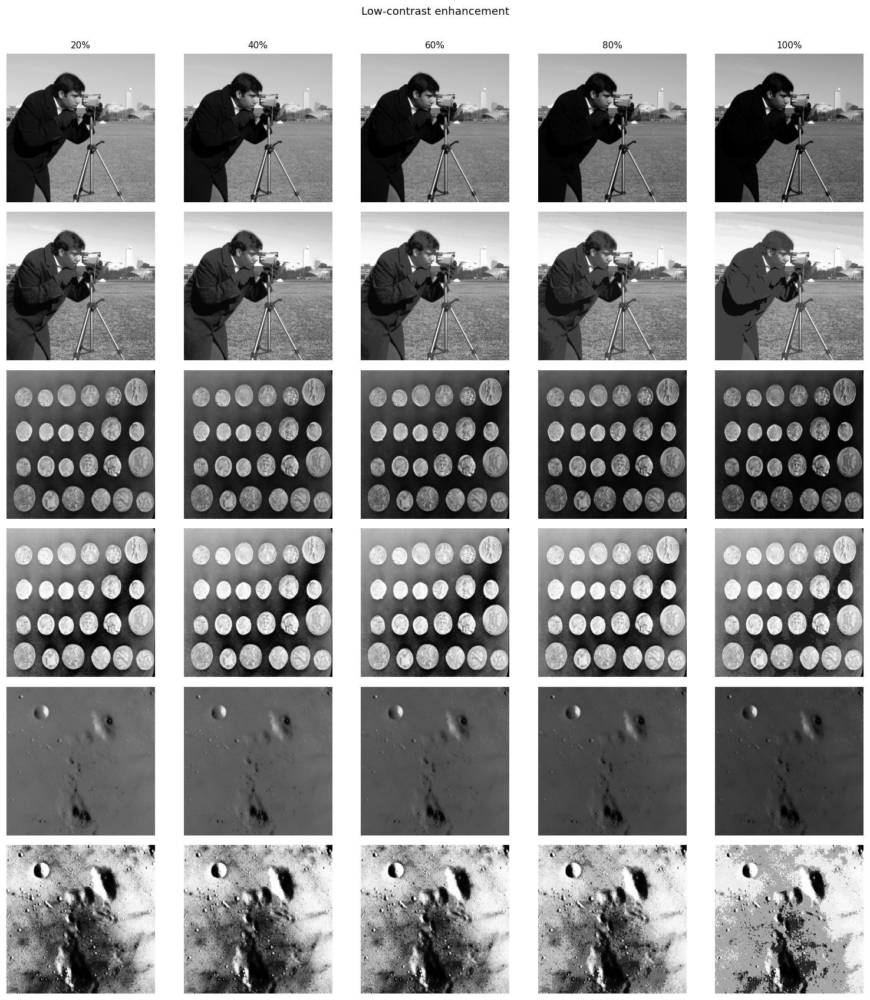

,Severity,Method,MSE,PSNR (dB),SSIM
0,20,Degraded input,0.00912,23.30,0.8869
1,20,Contrast stretching,0.00077,31.45,0.9913
2,20,Histogram equalization,0.03594,16.37,0.6449
3,40,Degraded input,0.01362,21.69,0.8445
4,40,Contrast stretching,0.00288,25.66,0.9729
5,40,Histogram equalization,0.03658,16.32,0.6411
6,60,Degraded input,0.01925,20.20,0.7927
7,60,Contrast stretching,0.00799,21.20,0.9308
8,60,Histogram equalization,0.03831,16.16,0.6313
9,80,Degraded input,0.02600,18.87,0.7312


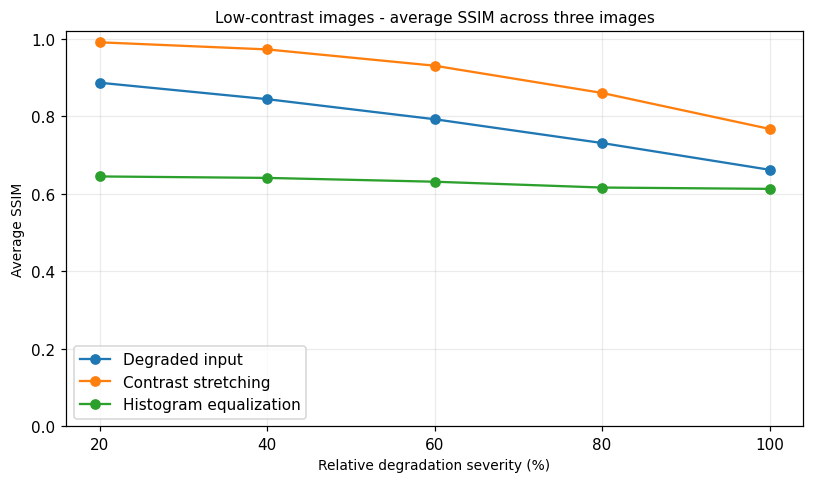

In [8]:
def contrast_stretch(image, out_min=0.0, out_max=1.0):
    image = image.astype(np.float64)
    in_min = float(image.min())
    in_max = float(image.max())

    if np.isclose(in_max, in_min):
        return np.full_like(image, out_min)

    stretched = (
        (image - in_min)
        * (out_max - out_min)
        / (in_max - in_min)
        + out_min
    )

    return clip01(stretched)

def histogram_equalization(image):
    image_u8 = np.rint(
        clip01(image) * 255
    ).astype(np.uint8)

    histogram = np.bincount(
        image_u8.ravel(),
        minlength=256,
    )
    probability = histogram / image_u8.size
    cdf = np.cumsum(probability)

    lookup = np.floor(
        255 * cdf
    ).astype(np.uint8)

    equalized_u8 = lookup[image_u8]
    return equalized_u8.astype(np.float64) / 255.0

low_stretch = apply_method_to_levels(
    low_levels,
    contrast_stretch,
)

low_equalized = apply_method_to_levels(
    low_levels,
    histogram_equalization,
)

low_methods = {
    "Contrast stretching": low_stretch,
    "Histogram equalization": low_equalized,
}

show_input_progression(
    low_levels,
    "Low-contrast inputs",
)

show_enhancement_progression(
    low_methods,
    "Low-contrast enhancement",
)

low_results = evaluate_problem(
    images,
    low_levels,
    low_methods,
)
low_average = average_metrics(low_results)

display(
    low_average.round({
        "MSE": 5,
        "PSNR (dB)": 2,
        "SSIM": 4,
    })
)

plot_ssim_trend(
    low_average,
    "Low-contrast images - average SSIM across three images",
)

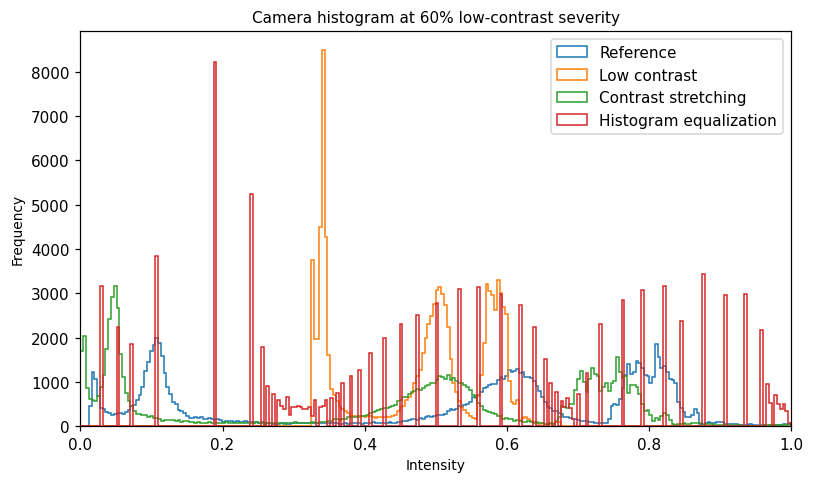

In [9]:
# One representative histogram comparison at 60% severity.
camera_60 = low_levels[60]["Camera"]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.hist(
    images["Camera"].ravel(),
    bins=256,
    range=(0, 1),
    histtype="step",
    label="Reference",
)
ax.hist(
    camera_60.ravel(),
    bins=256,
    range=(0, 1),
    histtype="step",
    label="Low contrast",
)
ax.hist(
    low_stretch[60]["Camera"].ravel(),
    bins=256,
    range=(0, 1),
    histtype="step",
    label="Contrast stretching",
)
ax.hist(
    low_equalized[60]["Camera"].ravel(),
    bins=256,
    range=(0, 1),
    histtype="step",
    label="Histogram equalization",
)
ax.set_title("Camera histogram at 60% low-contrast severity")
ax.set_xlabel("Intensity")
ax.set_ylabel("Frequency")
ax.set_xlim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()


### Observation

Contrast stretching consistently moves the images much closer to the reference, but its quality still drops as the nonlinear part of the degradation becomes stronger. That is expected because min-max stretching can restore the range, but it can't undo every nonlinear change.

Histogram equalization is much more aggressive. Visually, it produces stronger contrast, but its SSIM is lower for these images and the 80%-100% cases show increasingly obvious "posterization".

## 7. Spatial convolution

$$
G[i,j]
=
\sum_{u=-k}^{k}
\sum_{v=-k}^{k}
H[u,v]\,F[i-u,j-v]
$$

The kernel is rotated by $180^\circ$ before it is applied. The function below performs that rotation explicitly.

Reflection padding is used only for boundary handling; the filtering calculation itself is implemented here.


In [10]:
def convolve2d(image, kernel, padding="reflect"):
    image = np.asarray(image, dtype=np.float64)
    kernel = np.asarray(kernel, dtype=np.float64)

    if image.ndim != 2 or kernel.ndim != 2:
        raise ValueError("image and kernel must both be 2-D")

    kh, kw = kernel.shape

    if kh % 2 == 0 or kw % 2 == 0:
        raise ValueError("kernel dimensions must be odd")

    pad_h = kh // 2
    pad_w = kw // 2

    padded = np.pad(
        image,
        ((pad_h, pad_h), (pad_w, pad_w)),
        mode=padding,
    )

    windows = sliding_window_view(
        padded,
        (kh, kw),
    )

    flipped_kernel = kernel[::-1, ::-1]

    return np.einsum(
        "ijkl,kl->ij",
        windows,
        flipped_kernel,
    )

def gaussian_kernel(size, sigma):
    if size % 2 == 0:
        raise ValueError("kernel size must be odd")

    radius = size // 2
    axis = np.arange(
        -radius,
        radius + 1,
        dtype=np.float64,
    )
    x, y = np.meshgrid(axis, axis)

    kernel = np.exp(
        -(x**2 + y**2)
        / (2 * sigma**2)
    )
    kernel /= kernel.sum()

    return kernel

identity_kernel = np.array([
    [0, 0, 0],
    [0, 1, 0],
    [0, 0, 0],
], dtype=np.float64)

identity_check = convolve2d(
    images["Camera"],
    identity_kernel,
)

Identity-kernel maximum error: 0.0


## 8. Blurred-image enhancement

### Laplacian sharpening

I use the positive-center Laplacian mask

$$
\begin{bmatrix}
0 & -1 & 0 \\
-1 & 4 & -1 \\
0 & -1 & 0
\end{bmatrix}
$$

and sharpen with

$$
g = f + \alpha \nabla^2 f
$$

using a fixed $\alpha=2.5$.

### Unsharp masking

First, a Gaussian-smoothed image is created. The detail mask is

$$
m = f - f_{\mathrm{smooth}}
$$

and the sharpened result is

$$
g = f + k\,m
$$

with a fixed amount $k=2.0$.


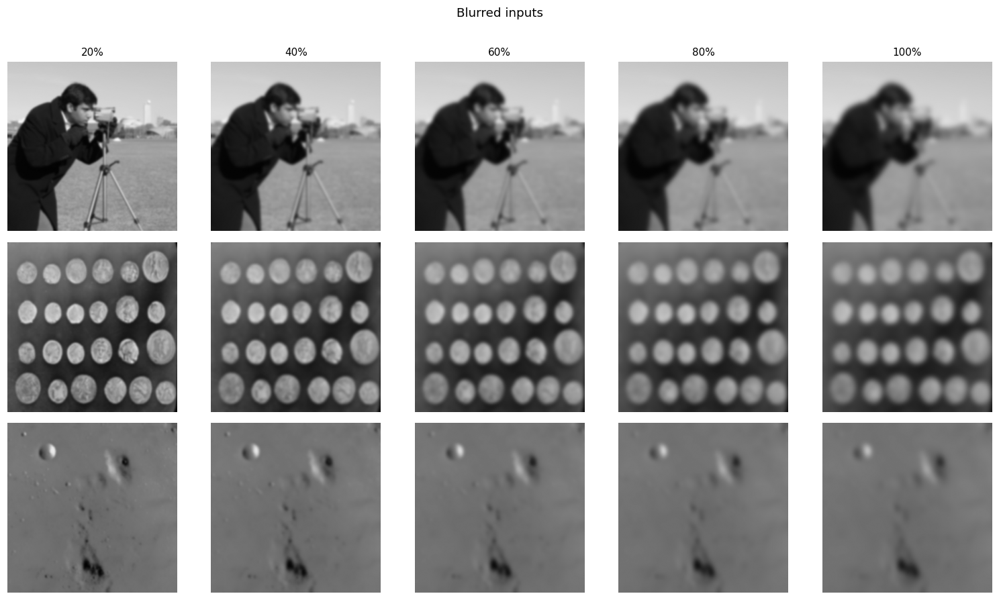

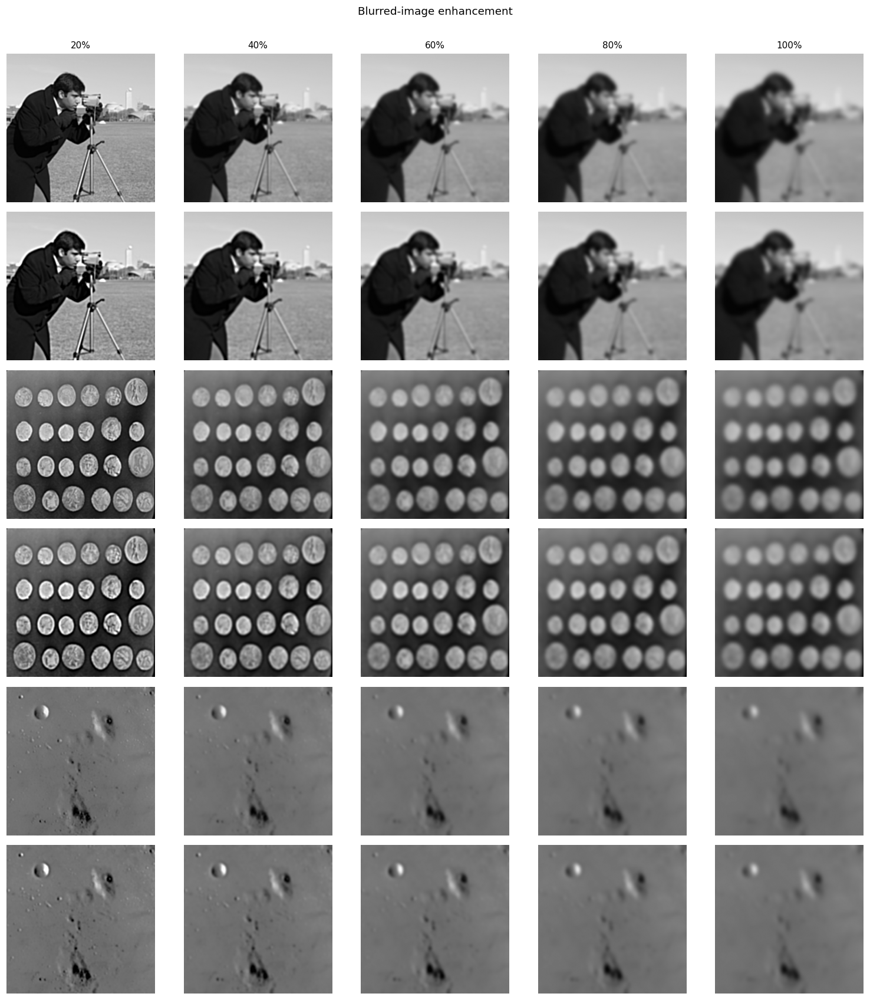

,Severity,Method,MSE,PSNR (dB),SSIM
0,20,Degraded input,0.00157,30.41,0.8506
1,20,Laplacian sharpening,0.00073,33.71,0.9230
2,20,Unsharp masking,0.00202,29.21,0.8651
3,40,Degraded input,0.00272,27.97,0.7737
4,40,Laplacian sharpening,0.00182,29.76,0.8277
5,40,Unsharp masking,0.00188,29.60,0.8213
6,60,Degraded input,0.00368,26.61,0.7255
7,60,Laplacian sharpening,0.00303,27.50,0.7543
8,60,Unsharp masking,0.00261,28.18,0.7683
9,80,Degraded input,0.00454,25.64,0.6941


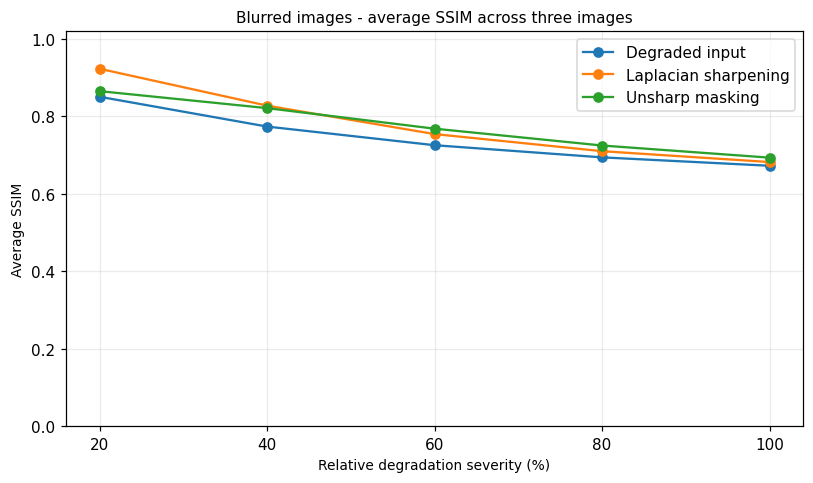

In [11]:
LAPLACIAN_KERNEL = np.array([
    [0, -1, 0],
    [-1, 4, -1],
    [0, -1, 0],
], dtype=np.float64)

UNSHARP_KERNEL = gaussian_kernel(
    size=13,
    sigma=3.0,
)

def laplacian_sharpen(image, alpha=2.5):
    laplacian_response = convolve2d(
        image,
        LAPLACIAN_KERNEL,
    )
    return clip01(
        image + alpha * laplacian_response
    )

def unsharp_mask(image, amount=2.0):
    smooth = convolve2d(
        image,
        UNSHARP_KERNEL,
    )
    detail = image - smooth
    return clip01(
        image + amount * detail
    )

blur_laplacian = apply_method_to_levels(
    blur_levels,
    lambda image: laplacian_sharpen(
        image,
        alpha=2.5,
    ),
)

blur_unsharp = apply_method_to_levels(
    blur_levels,
    lambda image: unsharp_mask(
        image,
        amount=2.0,
    ),
)

blur_methods = {
    "Laplacian sharpening": blur_laplacian,
    "Unsharp masking": blur_unsharp,
}

show_input_progression(
    blur_levels,
    "Blurred inputs",
)

show_enhancement_progression(
    blur_methods,
    "Blurred-image enhancement",
)

blur_results = evaluate_problem(
    images,
    blur_levels,
    blur_methods,
)
blur_average = average_metrics(blur_results)

display(
    blur_average.round({
        "MSE": 5,
        "PSNR (dB)": 2,
        "SSIM": 4,
    })
)

plot_ssim_trend(
    blur_average,
    "Blurred images - average SSIM across three images",
)

### Observation

Laplacian sharpening gives the larger improvement at 20% and 40% blur, where there is still enough edge information to emphasize. At the stronger blur levels, unsharp masking becomes slightly better on average.

After roughly 60% severity, both enhanced curves keep falling because the blur has removed more high-frequency detail than a sharpening operation can recover. The images may look sharper at some boundaries, but they are not genuinely restored to the original.

## 9. Overall comparison

The table below collects the average result over all three images for every severity and every method.


In [12]:
def add_problem_name(table, problem):
    result = table.copy()
    result.insert(0, "Problem", problem)
    return result

overall_average = pd.concat(
    [
        add_problem_name(dark_average, "Dark"),
        add_problem_name(bright_average, "Bright"),
        add_problem_name(low_average, "Low contrast"),
        add_problem_name(blur_average, "Blur"),
    ],
    ignore_index=True,
)

display(
    overall_average.round({
        "MSE": 5,
        "PSNR (dB)": 2,
        "SSIM": 4,
    })
)

,Problem,Severity,Method,MSE,PSNR (dB),SSIM
0,Dark,20,Degraded input,0.05049,13.06,0.6630
1,Dark,20,Log transform,0.02850,15.62,0.7704
2,Dark,20,Gamma 0.45,0.00047,33.56,0.9947
3,Dark,40,Degraded input,0.08431,10.80,0.4905
4,Dark,40,Log transform,0.05951,12.37,0.5977
5,Dark,40,Gamma 0.45,0.00337,24.76,0.9816
6,Dark,60,Degraded input,0.11353,9.49,0.3607
7,Dark,60,Log transform,0.08927,10.57,0.4548
8,Dark,60,Gamma 0.45,0.01451,18.44,0.9052
9,Dark,80,Degraded input,0.13757,8.65,0.2662


In [13]:
# Best enhancement method by average SSIM at each severity.
best_rows = []

for problem in overall_average["Problem"].unique():
    problem_table = overall_average[
        overall_average["Problem"] == problem
    ]

    for severity in SEVERITIES:
        candidates = problem_table[
            (problem_table["Severity"] == severity)
            & (problem_table["Method"] != "Degraded input")
        ]

        best = candidates.loc[
            candidates["SSIM"].idxmax()
        ]

        best_rows.append({
            "Problem": problem,
            "Severity": severity,
            "Best enhancement": best["Method"],
            "Average SSIM": best["SSIM"],
        })

best_by_severity = pd.DataFrame(best_rows)

display(
    best_by_severity.round({
        "Average SSIM": 4,
    })
)


,Problem,Severity,Best enhancement,Average SSIM
0,Dark,20,Gamma 0.45,0.9947
1,Dark,40,Gamma 0.45,0.9816
2,Dark,60,Gamma 0.45,0.9052
3,Dark,80,Gamma 0.45,0.8052
4,Dark,100,Gamma 0.45,0.7044
5,Bright,20,Gamma 1.8,0.9540
6,Bright,40,Gamma 1.8,0.9971
7,Bright,60,Gamma 2.4,0.9894
8,Bright,80,Gamma 2.4,0.9409
9,Bright,100,Gamma 2.4,0.7926


## 10. Conclusion

- For **dark images**, gamma 0.45 works very well at the lower levels but begins to under-correct once the darkening becomes severe.
- For **bright images**, a smaller correction works better early, while a stronger gamma becomes more useful later. Very strong brightening also introduces clipping, which cannot be undone.
- For **low contrast**, contrast stretching is much more faithful to the reference than histogram equalization in this experiment. Histogram equalization can create stronger-looking contrast while still moving farther from the original image.
- For **blur**, sharpening helps most while useful edge information is still present. After the middle severity levels, both Laplacian sharpening and unsharp masking show diminishing returns.

The main thing that we can take is that the same algorithm and parameter can work well for one degradation level and become unsuitable for another.

### References

Course material: *Image Enhancement* and *Image Enhancement Based on Filtering*.  
R. C. Gonzalez and R. E. Woods, *Digital Image Processing*.